# Celeba

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import lightning as L
import torch
import os, sys
import numpy as np
import pickle
sys.path.append("/home/taehui/causally-reliable-cbm/")
#from src.data.datasets.bndataset import BNDataset
import networkx as nx
from utils import *
torch.manual_seed(0)
np.random.seed(0)



In [ ]:
data_path = "/home/taehui/.cache/c2bm/celeba/preprocessed_dataset_1.pkl"
data = pd.read_pickle(data_path)

train = data['train']
val   = data['val']
test  = data['test']

print(train.shape)  # expect (N, 10)

torch.Size([162770, 9])


In [3]:
concept_order = [
    "Attractive",
    "Big_Lips",
    "Heavy_Makeup",
    "High_Cheekbones",
    "Male",
    "Oval_Face",
    "Smiling",
    "Wavy_Hair",
    "Wearing_Lipstick",
    "Mouth_Slightly_Open"  # <-- Task
]

task_name = "Mouth_Slightly_Open"
task_index = concept_order.index(task_name)
print("Task index =", task_index)

Task index = 9


In [5]:
graph_path = "/home/taehui/causally-reliable-cbm/learned_graphs/celeba/graph.pkl"
adj_pd = pd.read_pickle(graph_path)
graph = nx.from_pandas_adjacency(adj_pd, create_using=nx.DiGraph)

topo_order = list(nx.topological_sort(graph))
print("Topo order:", topo_order)


Topo order: ['Attractive', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Wearing_Lipstick', 'Wavy_Hair', 'Oval_Face', 'Big_Lips', 'Smiling', 'Mouth_Slightly_Open']


## gragh check

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ====== 1. Load adjacency matrix from pkl ======
pkl_path = "/home/taehui/causally-reliable-cbm/learned_graphs/celeba/graph.pkl"
adj_pd = pd.read_pickle(pkl_path)

print("Loaded adjacency matrix:")
print(adj_pd)

# ====== 2. Make full graph ======
full_graph = nx.from_pandas_adjacency(adj_pd, create_using=nx.DiGraph)

# Compute layout once so reduced graph keeps similar node positions
pos = nx.spring_layout(full_graph, seed=42, k=3)

# ====== 3. Draw full graph ======
plt.figure(figsize=(7, 5))
nx.draw(
    full_graph,
    pos=pos,
    with_labels=True,
    node_color='lightblue',
    node_size=800,
    font_size=10,
    font_weight='bold',
    arrowsize=18
)
plt.title("CelebA Learned Graph (Full)")
plt.tight_layout()
plt.show()


# ====== 4. Remove task node and draw reduced graph ======
task_name = "Mouth_Slightly_Open"   # 필요하면 다른 task로 변경

if task_name in adj_pd.index:
    adj_reduced = adj_pd.drop(task_name, axis=0).drop(task_name, axis=1)
else:
    print(f"[Warning] {task_name} not found in adjacency matrix. Skipping removal.")
    adj_reduced = adj_pd.copy()

reduced_graph = nx.from_pandas_adjacency(adj_reduced, create_using=nx.DiGraph)

# Reuse same pos dictionary but remove missing node entries
pos_reduced = {node: pos[node] for node in reduced_graph.nodes if node in pos}

plt.figure(figsize=(7, 5))
nx.draw(
    reduced_graph,
    pos=pos_reduced,
    with_labels=True,
    node_color='lightgreen',
    node_size=800,
    font_size=10,
    font_weight='bold',
    arrowsize=18
)
plt.title(f"CelebA Learned Graph (Task '{task_name}' Removed)")
plt.tight_layout()
plt.show()


In [ ]:

order = adj_pd.index.tolist()
topo_order = list(nx.topological_sort(reduced_graph))
print("Topological order of nodes:", topo_order)
print("Before topological order:", order)

topo_order_idx = [order.index(node) for node in topo_order]

# rearrange adj_pd with topo_order
adj_pd_topo = adj_pd.loc[topo_order, topo_order]
print(adj_pd_topo)
print(adj_pd)

adj_cnf = adj_pd_topo.to_numpy(dtype=np.int8).transpose(1,0)
adj_cnf += np.eye(adj_cnf.shape[0], dtype=np.int8)
adj_cnf



## CNF Learning and Inference on Sachs dataset

### Data check

In [8]:

def post_process(x, binary_dims, binary_min_values, binary_max_values, inplace=False):
    if not inplace:
        x = x.clone()
    x[..., binary_dims] = x[..., binary_dims].floor().float()
    x[..., binary_dims] = torch.clamp(x[..., binary_dims], min=binary_min_values, max=binary_max_values)

    return x

def add_noise(x):
    # Calculate the standard deviation of each column
    std = torch.std(x, dim=0).mul(100).round() / 100.0

    # Find the columns that are constant (i.e., have a standard deviation of 0)
    constant_mask = std == 0
    # # Generate a small amount of noise for each constant column
    # noise = torch.rand(x.shape[0], sum(constant_mask)) * 2.0 - 1.0
    noise = torch.randn(x.shape[0], sum(constant_mask))
    # Add the noise to the corresponding columns
    x[:, constant_mask] += noise * 0.01
    return x

In [9]:
# ---------------------------------------
# 1. Load concept-only dataset
# ---------------------------------------
train_C = train.float()   # shape (N, 9)
val_C   = val.float()
test_C  = test.float()

print(train_C.shape)

# ---------------------------------------
# 2. concept-only names (9 vars)
# ---------------------------------------
concept_order = [
    "Attractive",
    "Big_Lips",
    "Heavy_Makeup",
    "High_Cheekbones",
    "Male",
    "Oval_Face",
    "Smiling",
    "Wavy_Hair",
    "Wearing_Lipstick"
]

# ---------------------------------------
# 3. graph without task → topo order
# ---------------------------------------
topo_order = list(nx.topological_sort(reduced_graph))
print("Topo order:", topo_order)

# ---------------------------------------
# 4. Compute topo order indices (9 dims)
# ---------------------------------------
order = concept_order
topo_order_idx_C = [order.index(node) for node in topo_order]

print("Topo idx:", topo_order_idx_C)

# ---------------------------------------
# 5. Reorder according to topo order
# ---------------------------------------
train_C_topo = train_C[:, topo_order_idx_C]
val_C_topo   = val_C[:, topo_order_idx_C]
test_C_topo  = test_C[:, topo_order_idx_C]

# ---------------------------------------
# 6. Dequantization
# ---------------------------------------
binary_dims = list(range(train_C_topo.shape[1]))  # [0..8]

binary_min_values = train_C_topo.min(dim=0)[0]
binary_max_values = train_C_topo.max(dim=0)[0]

train_C_topo_deq = train_C_topo + torch.rand_like(train_C_topo)
val_C_topo_deq   = val_C_topo + torch.rand_like(val_C_topo)
test_C_topo_deq  = test_C_topo + torch.rand_like(test_C_topo)

print("Dequant:", train_C_topo_deq.shape)


torch.Size([162770, 9])
Topo order: ['Attractive', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Wearing_Lipstick', 'Wavy_Hair', 'Oval_Face', 'Big_Lips', 'Smiling']
Topo idx: [0, 2, 3, 4, 8, 7, 5, 1, 6]
Dequant: torch.Size([162770, 9])


In [10]:
def create_df(tensors_dict):
    df_list = []
    for name, x in tensors_dict.items():
        df = pd.DataFrame(x.numpy(), columns=[f'$x_{j}$' for j in range(x.shape[1])])
        df['name'] = name
        df_list.append(df)
    return pd.concat(df_list)

def plot_data(tensors_dict, mode="kde"):
    df = create_df(tensors_dict)
    g = sns.PairGrid(df, diag_sharey=False, hue='name')
    g.map_upper(sns.scatterplot, s=15, alpha=0.5)
    if mode == "kde":
        g.map_lower(sns.kdeplot, common_norm=False)
        g.map_diag(sns.kdeplot, lw=2, common_norm=False)
    else:
        g.map_lower(sns.histplot, bins=20)
        g.map_diag(sns.histplot, bins=20)
    g.add_legend()
    plt.show()

# example:
#plot_data({"test": test_C_topo_deq})


### Training

In [11]:

from torch.utils.data import DataLoader, TensorDataset
# Create the dataloaders
batch_size = 100
train_dataset = TensorDataset(train_C_topo_deq)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

test_dataset = TensorDataset(test_C_topo_deq)
test_loader = DataLoader(test_dataset, batch_size=test_C_topo_deq.shape[0])

In [12]:
from causalflows.flows import CausalMAF

features = train_C_topo_deq.shape[1]   # MUST be 9
context = 0
flow = CausalMAF(features, context, adjacency=adj_cnf)




# init the autoencoder
model = LitFlow(flow)

logger = MyLogger()
trainer = L.Trainer(
    max_epochs=200, logger=logger, enable_checkpointing=False, log_every_n_steps=len(train_loader)
)
trainer.fit(model=model, train_dataloaders=train_loader)

Trainer will use only 1 of 6 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=6)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA RTX 6000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5]

  | Name | Type      | Params | Mode  | FLOPs
---------------------------------------------------
0 | flow | CausalMAF | 6.0 K  | train | 0    
---------------------------------------------------
6.0 K     Trainable 

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


save model

In [13]:
save_file = "cnf_bundle.pt"

torch.save({
    "state_dict": model.flow.state_dict(),
    "features": train_C_topo.shape[1],   # 9
    "context": context,
    "adjacency": adj_cnf,                # 9×9

    # Indexing / ordering information
    "topo_order_idx": topo_order_idx_C,  # concept-only topo index
    "original_order": concept_order,     # raw concept names order
    "topological_order": topo_order,     # concept-only topo node names

    # Preprocessing
    "binary_dims": binary_dims,
    "binary_min_values": binary_min_values,
    "binary_max_values": binary_max_values,

}, save_file)


load model (optional)

In [15]:
save_file = "cnf_bundle.pt"
bundle = torch.load(save_file, map_location="cpu",weights_only=False)
flow_loaded = CausalMAF(bundle["features"], bundle["context"], adjacency=bundle["adjacency"])
flow_loaded.load_state_dict(bundle["state_dict"])
flow_loaded.eval()

CausalMAF(
  (transform): MaskedAutoregressiveTransform(
    (base): MonotonicAffineTransform()
    (passes): 5
    (hyper): MaskedMLP(
      (0): MaskedLinear(in_features=9, out_features=64, bias=True)
      (1): ReLU()
      (2): MaskedLinear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): MaskedLinear(in_features=64, out_features=18, bias=True)
    )
  )
  (base): UnconditionalDistribution(DiagNormal(loc: torch.Size([9]), scale: torch.Size([9])))
)

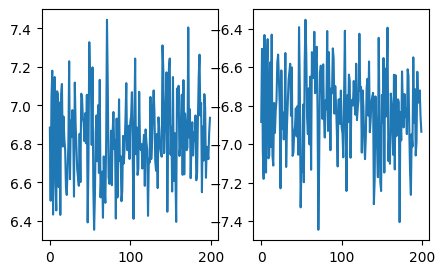

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(5, 3))
sns.lineplot(x=logger.values['epoch'], y=logger.values['train_loss'], ax=axs[0])
sns.lineplot(x=logger.values['epoch'], y=logger.values['log_prob'], ax=axs[1])
plt.show()

### Inference

observational

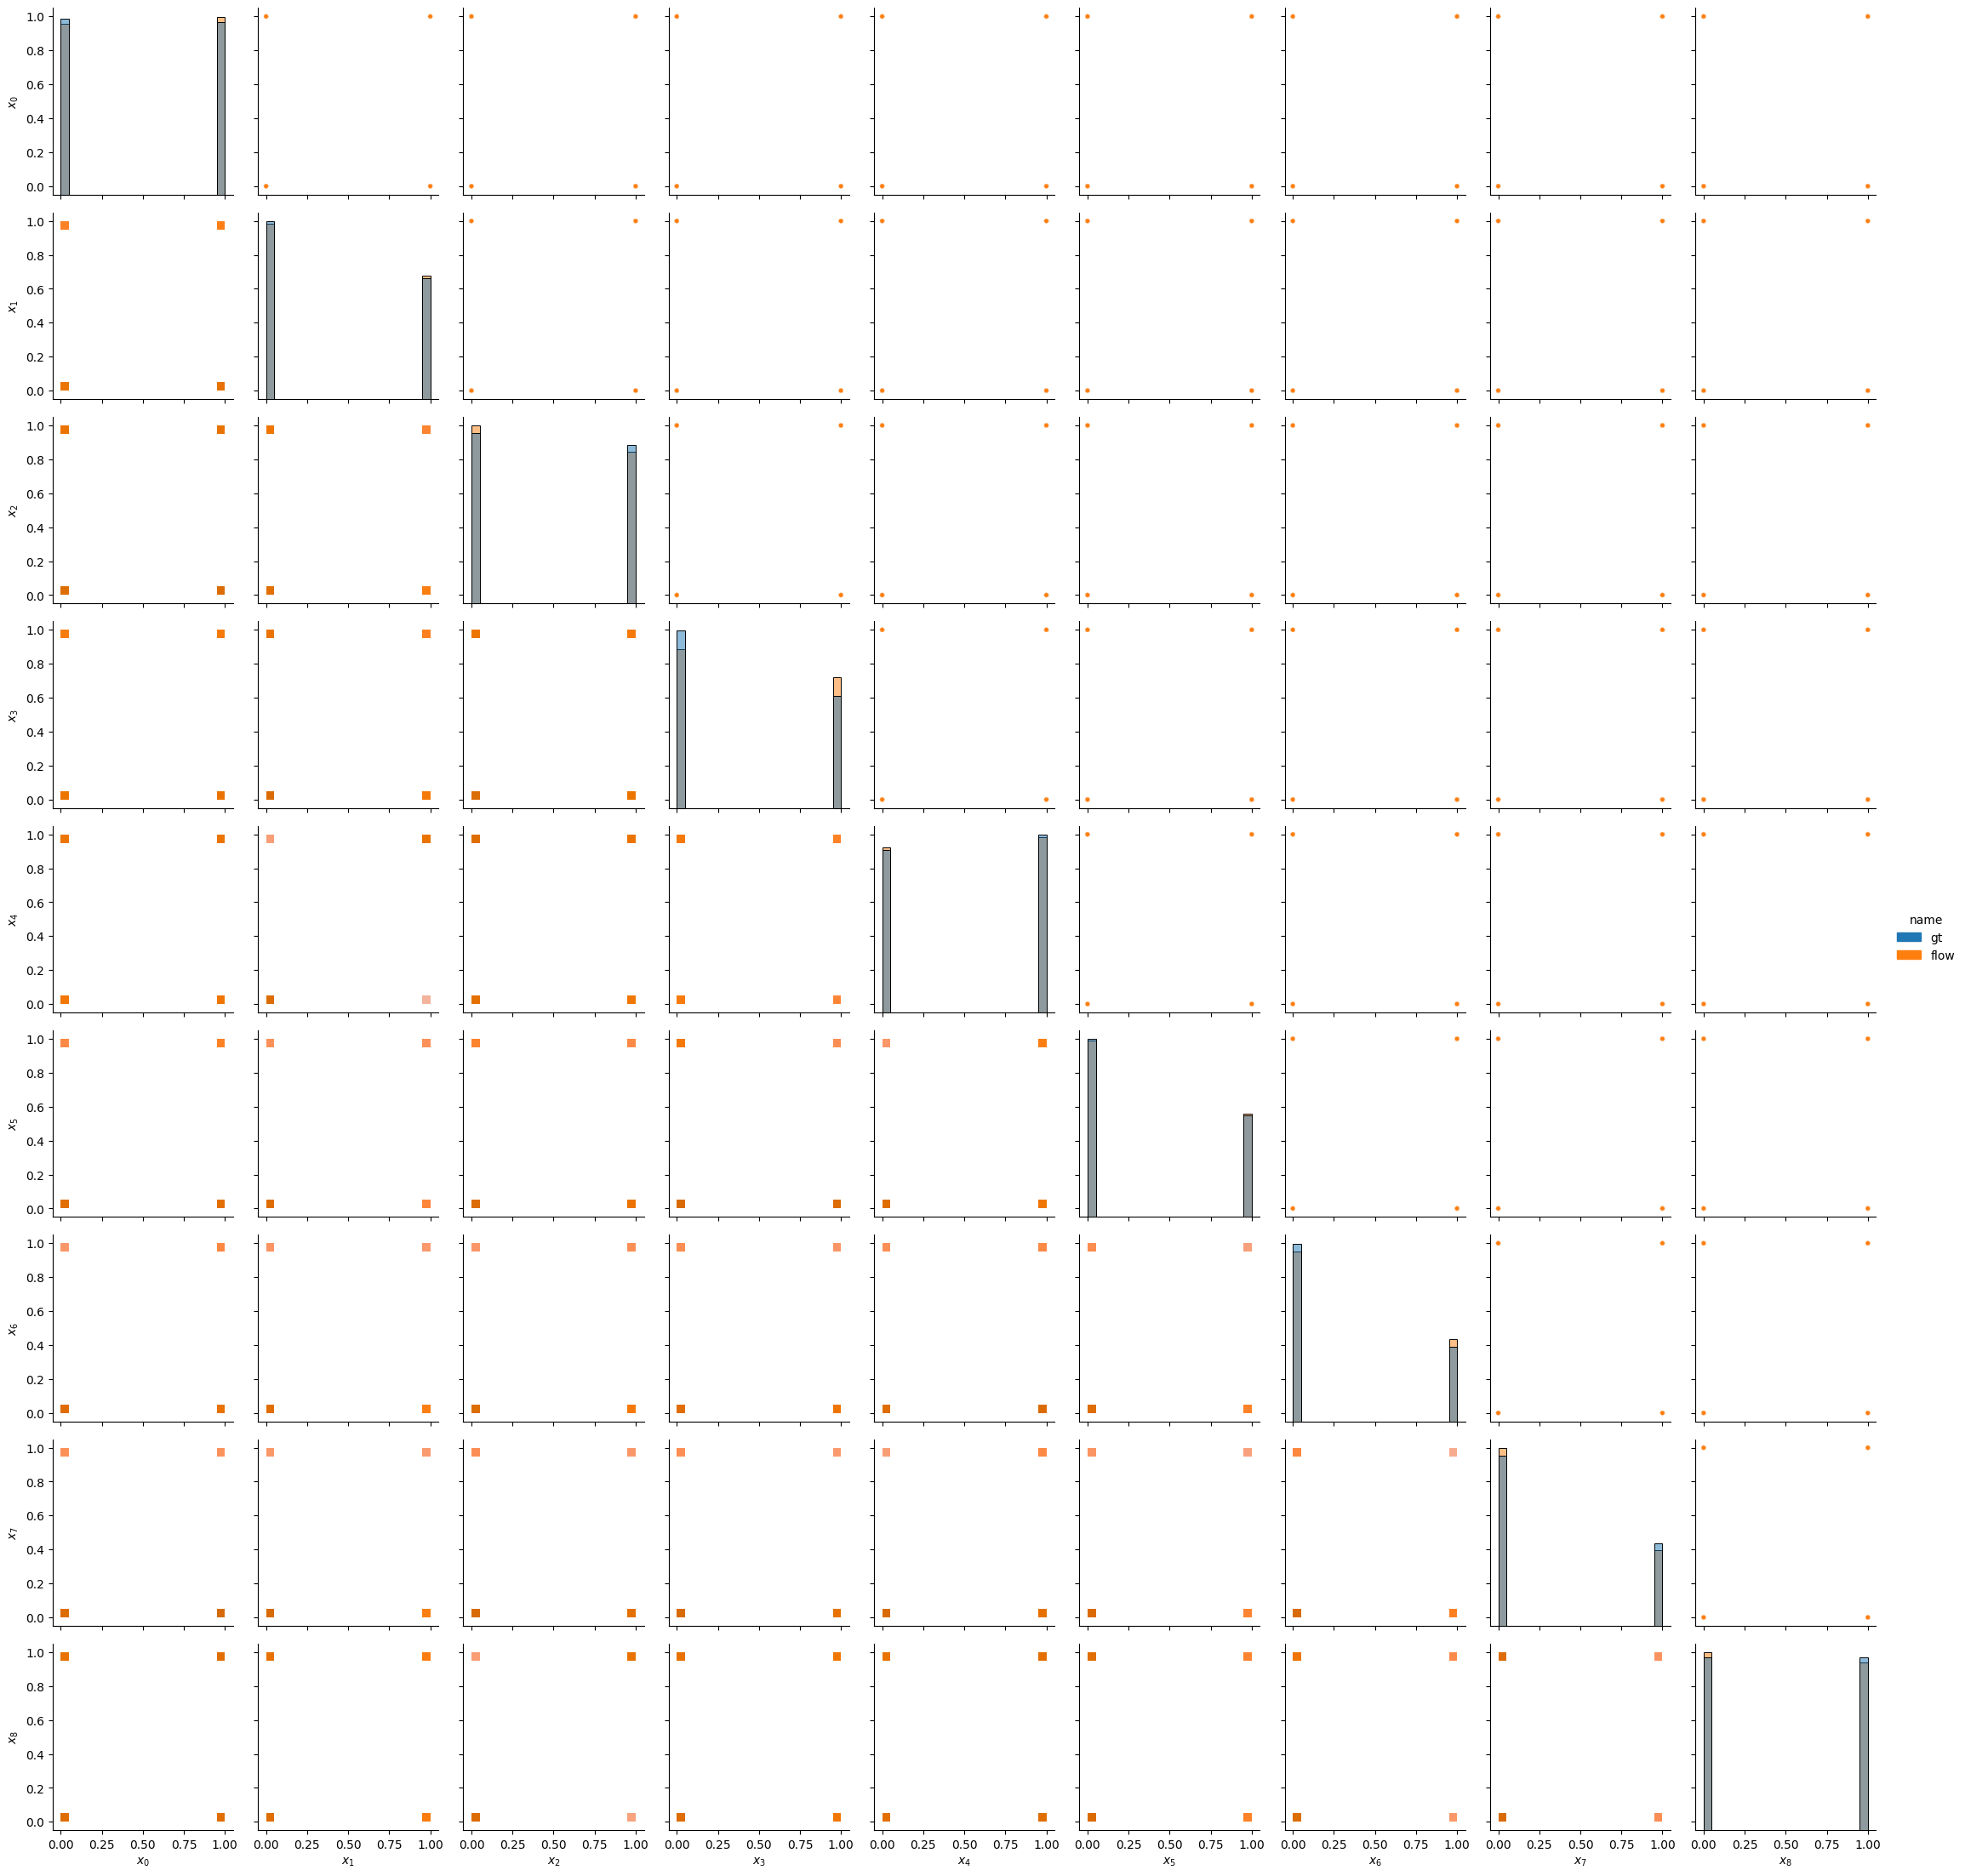

In [17]:
# observational
gt_obs = post_process(test_C_topo_deq, binary_dims, binary_min_values, binary_max_values)
obs_data =flow().sample([test_C_topo_deq.shape[0]])
obs_data = post_process(obs_data, binary_dims, binary_min_values, binary_max_values)

plot_data({'gt': gt_obs, 'flow': obs_data}, "hist")


interventional

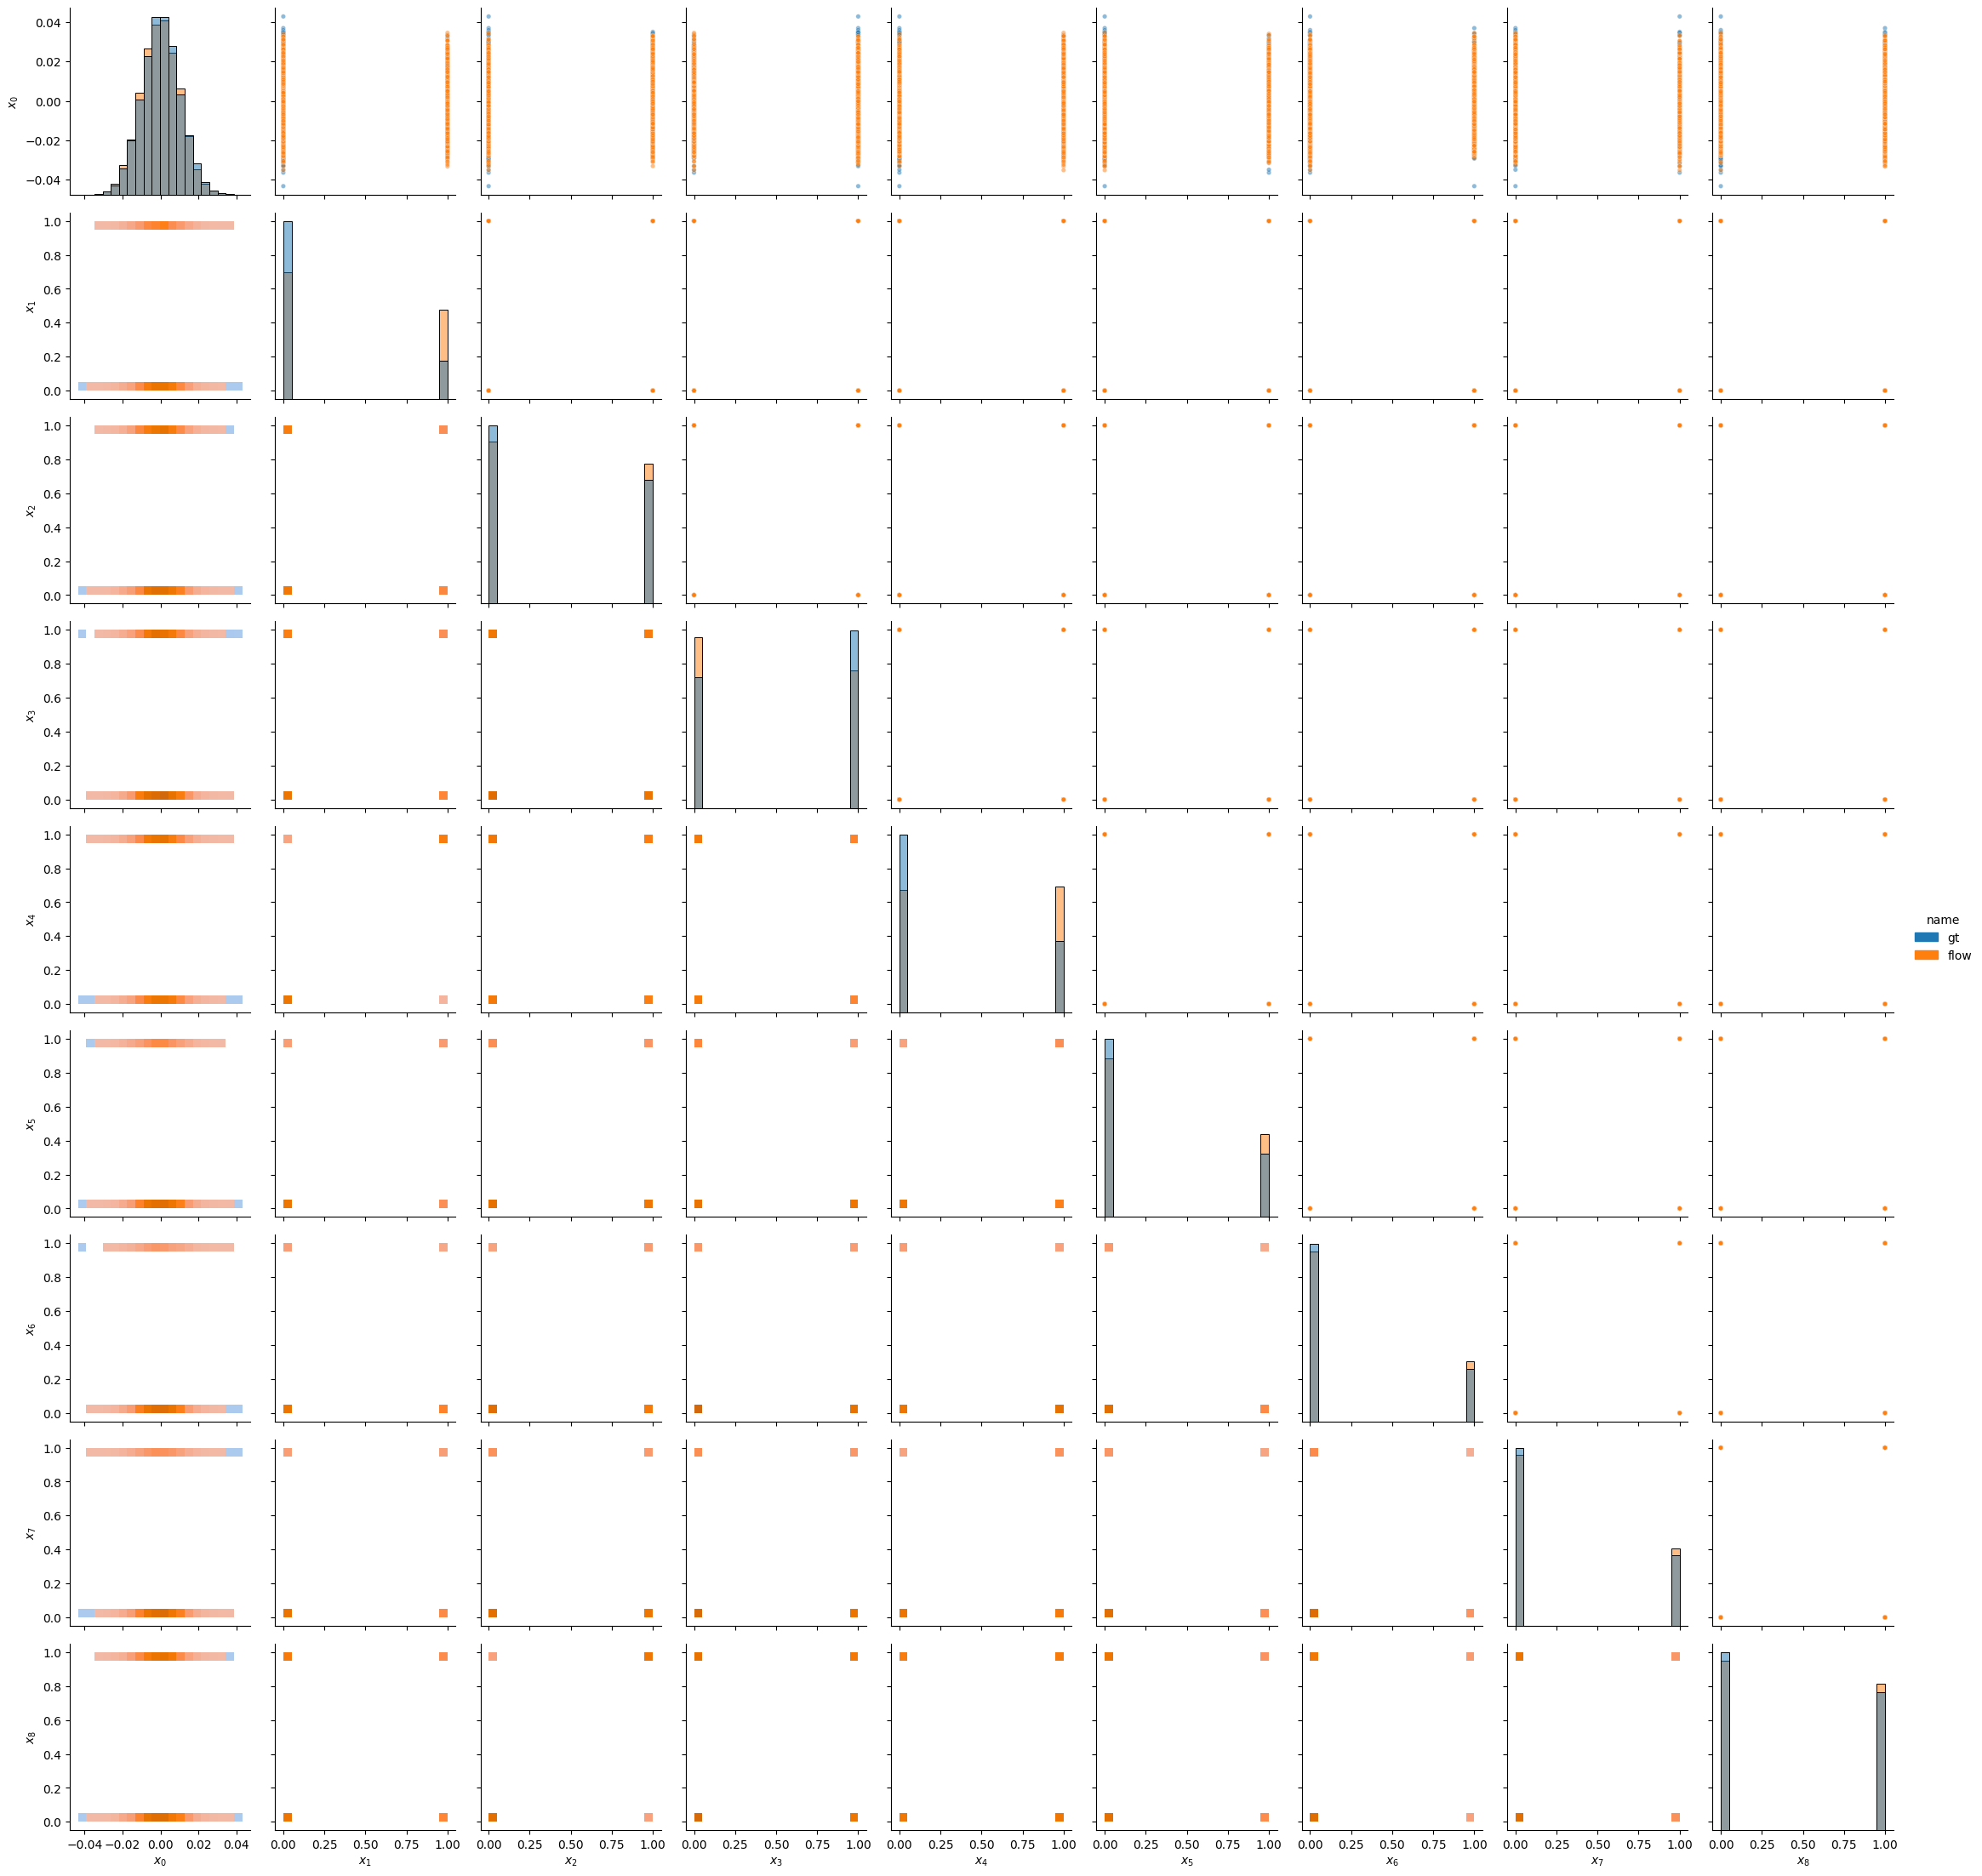

In [18]:
# intervention
index, value = 0, 0

#"simple" ground truth : conditional on root is same as intervention on root
mask = test_C_topo_deq[..., index].floor() == int(value)
int_gt = test_C_topo_deq[mask, :]
int_gt = add_noise(post_process(int_gt, binary_dims, binary_min_values, binary_max_values))

#generate intervention data
int_data = flow().sample_interventional(index=0, value=0+torch.rand(1), sample_shape=(int_gt.shape[0],))
int_data = add_noise(post_process(int_data, binary_dims, binary_min_values, binary_max_values))

#plot
plot_data({'gt': int_gt, 'flow': int_data}, "hist")


counterfactual

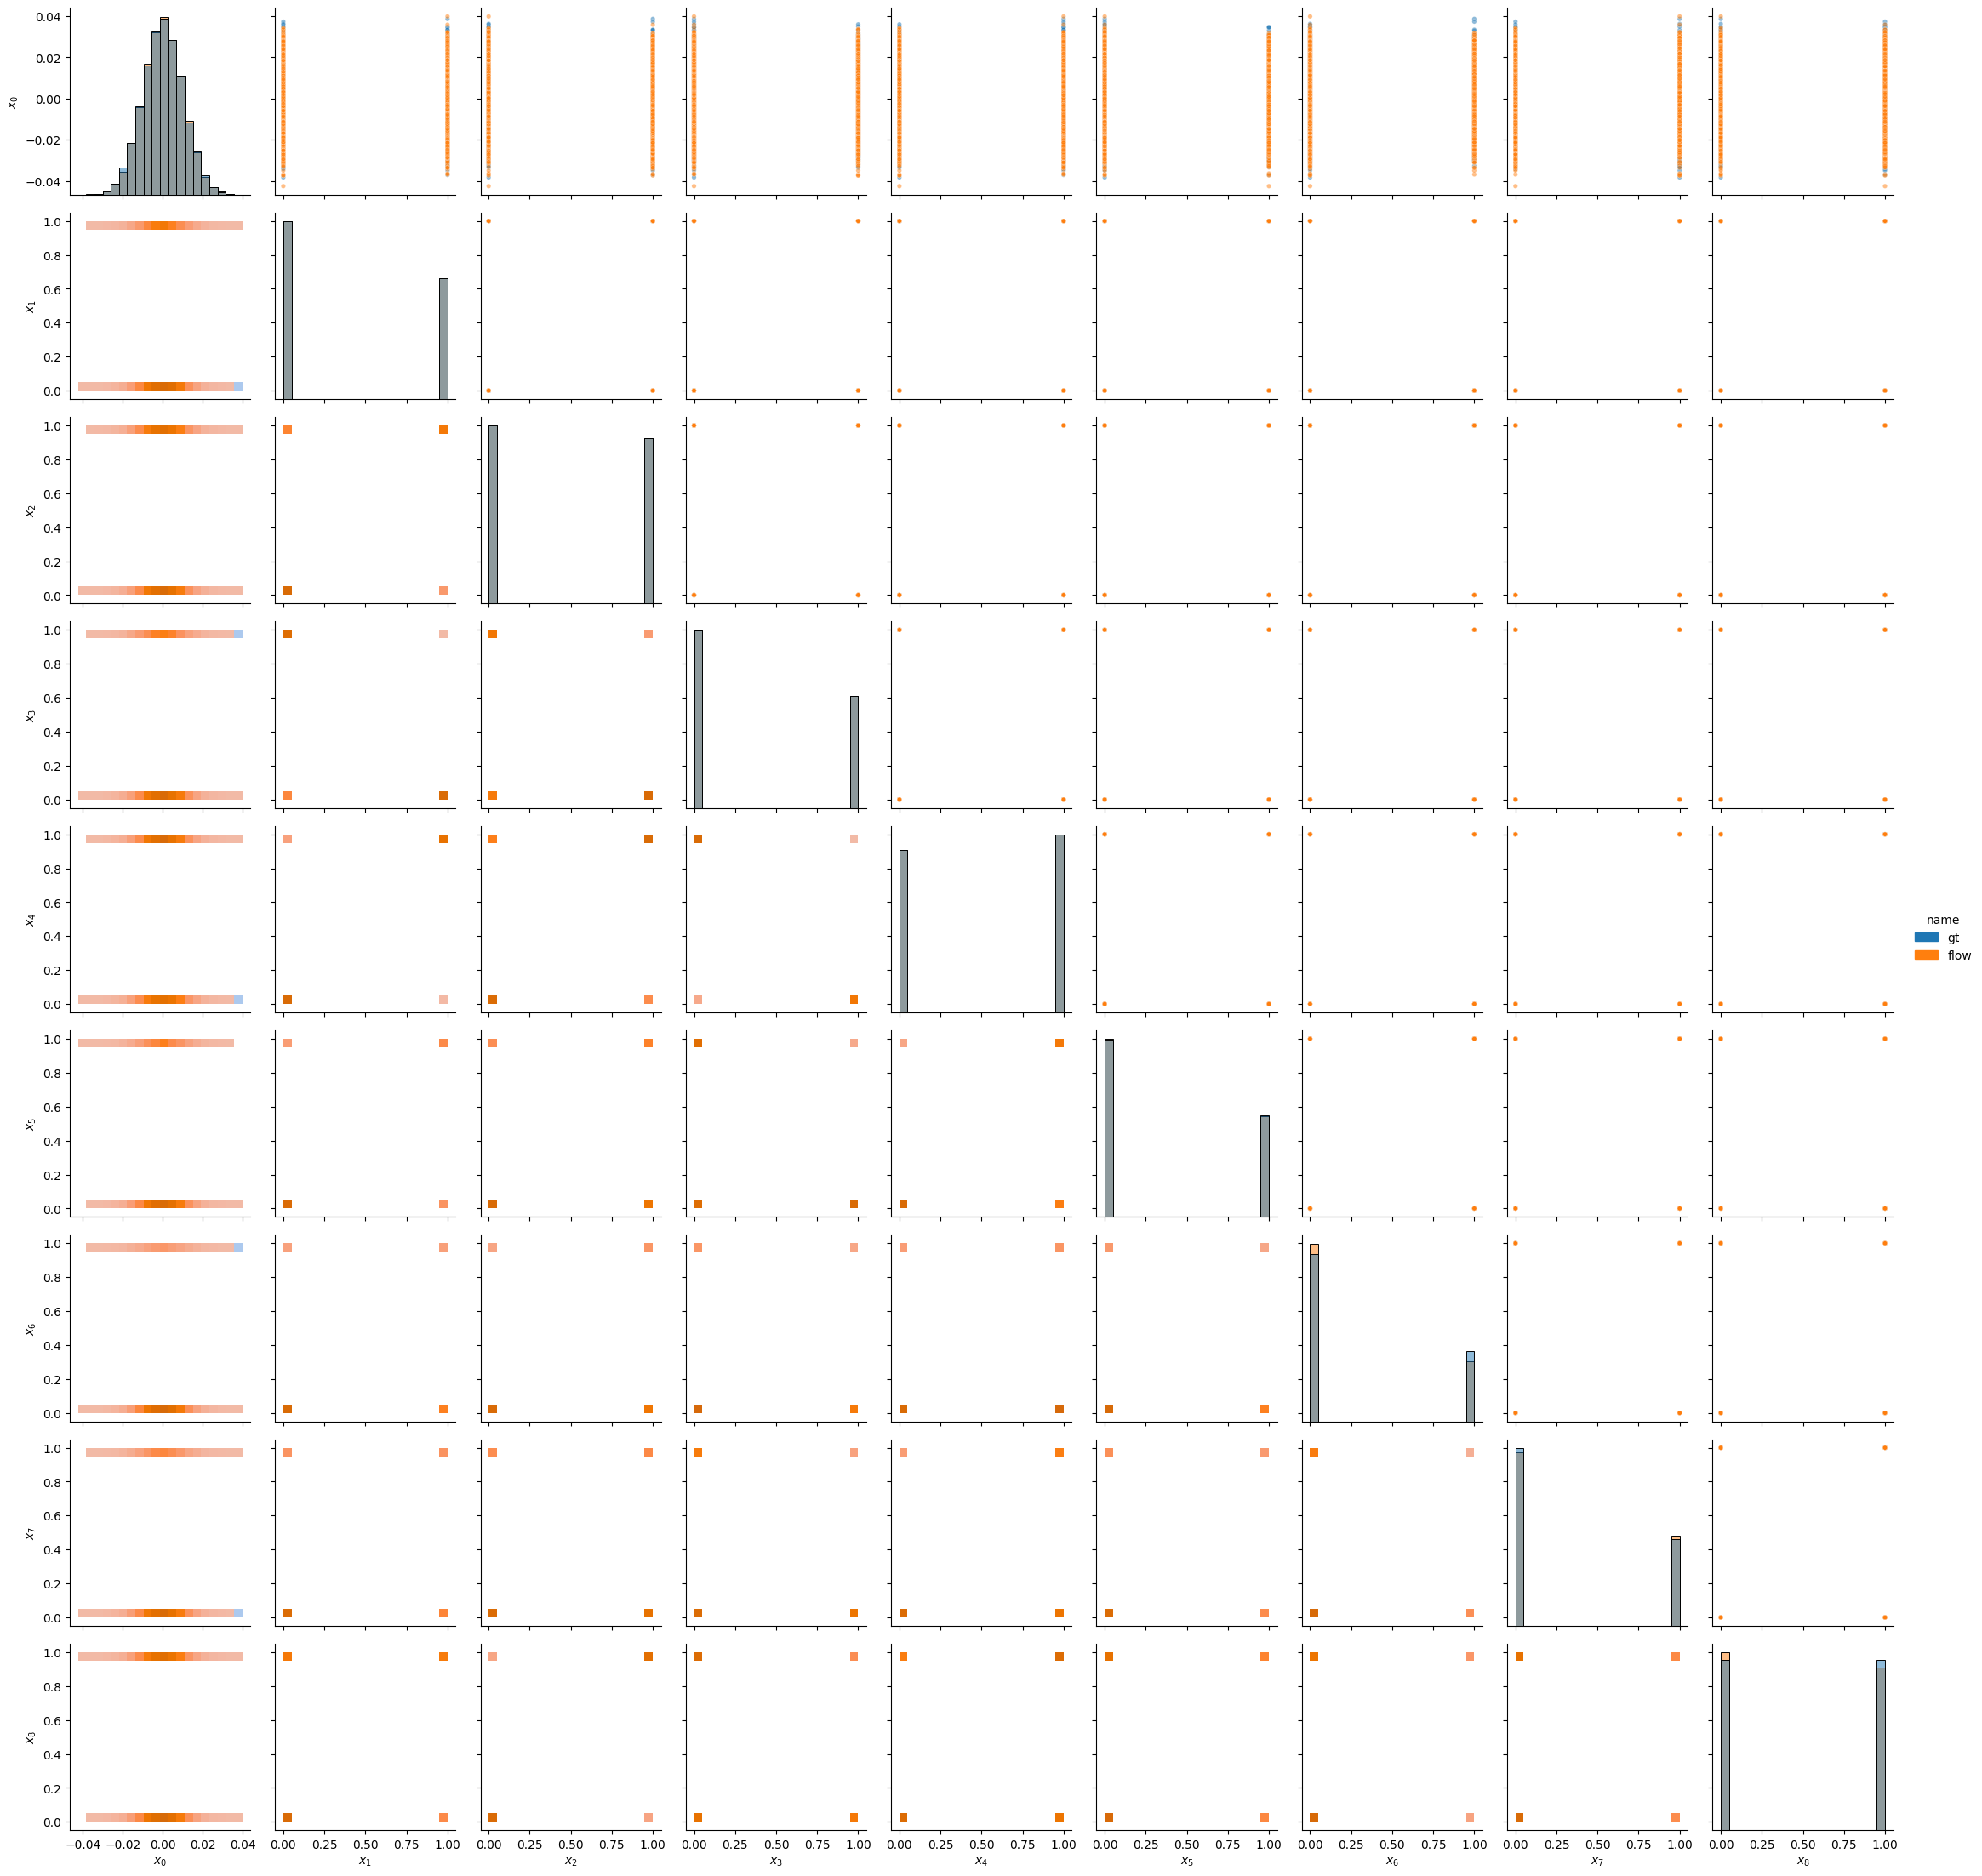

In [19]:
# intervention
index, value = 0, 0
x_cf = test_C_topo_deq.clone()


#"simple" ground truth : fixing value on root node of given factual data
cf_gt = x_cf.clone()
cf_gt[..., index] = value
cf_gt = add_noise(post_process(cf_gt, binary_dims, binary_min_values, binary_max_values))

#generate intervention data
cf_data = flow().compute_counterfactual(x_cf, index=0, value=0+torch.rand(1)).detach().cpu()
cf_data = add_noise(post_process(cf_data, binary_dims, binary_min_values, binary_max_values))

#plot
plot_data({'gt': cf_gt, 'flow': cf_data}, "hist")

## CBM, Causal Analysis.
* First, train vanilla, CBM or C2BM
* Then, extract 'predicted/inferenced' concept labels, corresponding to test dataset samples
* Analyzing distributional gaps between latent representations of true concepts and those derived from predicted concepts. (for 'Leakge analysis')
* Generate counterfactual concept predictions when given factual inputs, and apply them to (Causal)CBM as 'concept interventions' on test time

#### Leakage Analysis

In [73]:
'''
<CBM>
'''
# run_id, incomplete_concepts = "2025-12-07/20-38-14_sachs_complete", None
# run_id, incomplete_concepts = "2025-12-08/13-31-39_sachs_incomplete", ["Mek", "Jnk", "Raf"]
# run_id, incomplete_concepts = "2025-12-07/21-24-11_sachs_incomplete2", ["PIP3", "PIP2", "Plcg"]
# run_id, incomplete_concepts = "2025-12-07/21-39-42_sachs_complete_soft", None
# run_id, incomplete_concepts = "2025-12-08/13-27-41_sachs_incomplete_soft", ["Mek", "Jnk", "Raf"]
# run_id, incomplete_concepts = "2025-12-07/21-41-26_sachs_incomplete2_soft", ["PIP3", "PIP2", "Plcg"]
# run_id, incomplete_concepts = "2025-12-08/18-47-42_sachs_incomplete3", ["Erk", "PKA", "Mek", "PKC", "Raf"]
# run_id, incomplete_concepts = "2025-12-08/18-48-40_sachs_incomplete3_soft", ["Erk", "PKA", "Mek", "PKC", "Raf"]

'''
<CEM>
'''
# run_id, incomplete_concepts = "2025-12-08/13-53-56_cem_sachs_complete", None
# run_id, incomplete_concepts = "2025-12-08/13-56-25_cem_sachs_incomplete", ["PIP3", "PIP2", "Plcg"]
# run_id, incomplete_concepts = "2025-12-08/13-57-24_cem_sachs_complete_soft", None
# run_id, incomplete_concepts = "2025-12-08/13-58-18_cem_sachs_incomplete_soft", ["PIP3", "PIP2", "Plcg"]
# run_id, incomplete_concepts = "2025-12-08/18-49-21_cem_sachs_incomplete3", ["Erk", "PKA", "Mek", "PKC", "Raf"]
run_id, incomplete_concepts = "2025-12-08/18-51-43_cem_sachs_incomplete3_soft", ["Erk", "PKA", "Mek", "PKC", "Raf"]

'''
<C2BM>
'''
# run_id, incomplete_concepts = "2025-12-08/14-10-48_c2bm_sachs_complete", ['Erk', 'PKA', 'Mek', 'PKC', 'Raf']
# run_id, incomplete_concepts = "2025-12-08/14-17-48_c2bm_sachs_complete_soft", ['Erk', 'PKA', 'Mek', 'PKC', 'Raf']


'\n<C2BM>\n'

In [22]:
save_file = "cnf_bundle.pt"
from causalflows.flows import CausalMAF
bundle = torch.load(save_file, map_location="cpu",weights_only=False)
flow_loaded = CausalMAF(bundle["features"], bundle["context"], adjacency=bundle["adjacency"])
flow_loaded.load_state_dict(bundle["state_dict"])
flow_loaded.eval()

CausalMAF(
  (transform): MaskedAutoregressiveTransform(
    (base): MonotonicAffineTransform()
    (passes): 5
    (hyper): MaskedMLP(
      (0): MaskedLinear(in_features=9, out_features=64, bias=True)
      (1): ReLU()
      (2): MaskedLinear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): MaskedLinear(in_features=64, out_features=18, bias=True)
    )
  )
  (base): UnconditionalDistribution(DiagNormal(loc: torch.Size([9]), scale: torch.Size([9])))
)

In [23]:
topo_order_idx = bundle["topo_order_idx"]
original_order = bundle["original_order"]
topological_order = bundle["topological_order"]
binary_dims = bundle["binary_dims"]
binary_min_values = bundle["binary_min_values"]
binary_max_values = bundle["binary_max_values"]
print(original_order)
print(topological_order)

['Attractive', 'Big_Lips', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Oval_Face', 'Smiling', 'Wavy_Hair', 'Wearing_Lipstick']
['Attractive', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Wearing_Lipstick', 'Wavy_Hair', 'Oval_Face', 'Big_Lips', 'Smiling']


extract ground truth concept labels and align to topological_order : complete concept set

extract predicted concept labels from CBM

Transform true/predicted concept labels to corresponding latent space

In [79]:
# plot_data({'u_gt': u_topo, 'u_hat': u_hat_topo}, "kde", col_names = incomplete_concepts if incomplete_concepts is not None else topological_order)

Metrics for Leakage Analysis (referece : Leakage and Interpretability in CBM, Parisini, Enrico, et al. 2025)
* CONCEPT-TASK LEAKAGE SCORE
    #  <img src="./CONCEPT_TASK_LEAKAGE_SCORE.png" width="500"/>
* INTERCONCEPT LEAKAGE SCORE
    #  <img src="./INTERCONCEPT_LEAKAGE_SCORE.png" width="500"/>

##### Metrics